# ***SECTION 1: IMPORTS & SETUP***

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
import emoji
# !pip install contractions
import contractions
from bs4 import BeautifulSoup
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
import pickle


In [13]:
# Download necessary NLTK data (quiet=True to avoid console spam)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

True

# ***SECTION 2: DATA LOADING & EXPLORATION***

In [4]:
df = pd.read_csv('IMDB Dataset.csv', engine='python')
print("--- Dataset Head ---")
print(df.head())

--- Dataset Head ---
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [5]:
print("\n--- Columns ---")
print(df.columns)


--- Columns ---
Index(['review', 'sentiment'], dtype='object')


In [7]:
print("\n--- Dataset Info ---")
df.info()


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [8]:
print("\n--- Duplicated Rows ---")
print(df.duplicated().sum())


--- Duplicated Rows ---
418


In [9]:
# Drop duplicates
df.drop_duplicates(inplace=True)
print("\nShape after dropping duplicates:", df.shape)


Shape after dropping duplicates: (49582, 2)


In [10]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
review       0
sentiment    0
dtype: int64


In [11]:
sentiment_distribution = df['sentiment'].value_counts()
print("\n--- Sentiment Distribution ---")
print(sentiment_distribution)


--- Sentiment Distribution ---
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


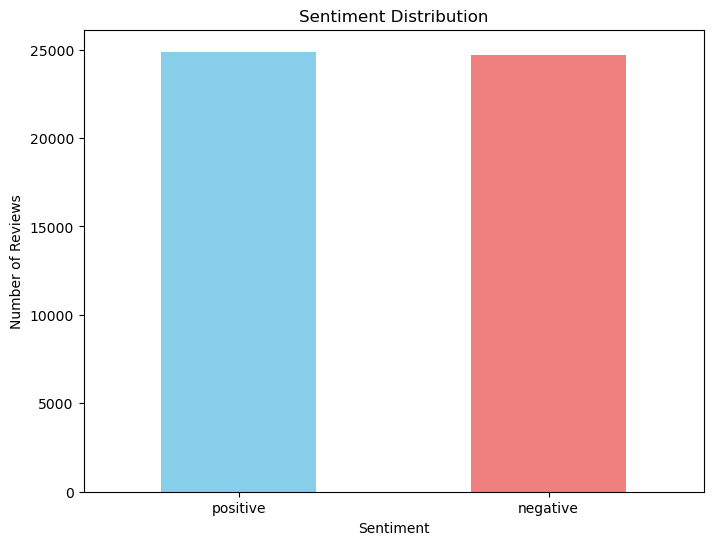

In [12]:
# Plot Sentiment Distribution
plt.figure(figsize=(8, 6))
sentiment_distribution.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

In [13]:
total_sentiments = sentiment_distribution.sum()
percentage_distribution = (sentiment_distribution / total_sentiments) * 100
print("\n--- Percentage Distribution ---")
print(percentage_distribution)


--- Percentage Distribution ---
sentiment
positive    50.187568
negative    49.812432
Name: count, dtype: float64


# ***SECTION 3: TEXT CLEANING***

In [14]:
# Convert to lowercase
df['review'] = df['review'].str.lower()

In [15]:
def remove_html_bs(text):
    soup = BeautifulSoup(str(text), "html.parser")
    return soup.get_text()
df["review"] = df["review"].apply(remove_html_bs)

C:\Users\shish\AppData\Local\Temp\ipykernel_20784\844874051.py:2: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(str(text), "html.parser")


In [21]:
def remove_url(text):
    return re.sub(r"https?://\S+|www\.\S+", "", text)
df["review"] = df["review"].apply(remove_url)

In [17]:
def remove_email(text):
    return re.sub(r"\S+@\S+", "", text)
df["review"] = df["review"].apply(remove_email)

In [19]:
def remove_emoji(text):
    return emoji.replace_emoji(text, replace="")
df["review"] = df["review"].apply(remove_emoji)

In [20]:
def expand_contractions(text):
    return contractions.fix(text)
df["review"] = df["review"].apply(expand_contractions)

In [22]:
def remove_special_char(text):
    return re.sub(r"[^a-zA-Z0-9\s]", "", text)
df["review"] = df["review"].apply(remove_special_char)

In [23]:
def remove_numbers(text):
    return re.sub(r"\d+", "", text)
df["review"] = df["review"].apply(remove_numbers)

In [24]:
def remove_extra_spaces(text):
    return re.sub(r"\s+", " ", text).strip()
df['review'] = df['review'].apply(remove_extra_spaces)

# ***SECTION 4: TOKENIZATION & PREPROCESSING***

In [25]:
df["review"] = df["review"].apply(word_tokenize)

In [26]:
df

,review,sentiment
0,"[one, of, the, other, reviewers, has, mentione...",positive
1,"[a, wonderful, little, production, the, filmin...",positive
2,"[i, thought, this, was, a, wonderful, way, to,...",positive
3,"[basically, there, is, a, family, where, a, li...",negative
4,"[petter, matteis, love, in, the, time, of, mon...",positive
...,...,...
49995,"[i, thought, this, movie, did, a, down, right,...",positive
49996,"[bad, plot, bad, dialogue, bad, acting, idioti...",negative
49997,"[i, am, a, catholic, taught, in, parochial, el...",negative
49998,"[i, am, going, to, have, to, disagree, with, t...",negative


In [27]:
stop_words = set(stopwords.words("english"))
def remove_stopwords(tokens):
    return [word for word in tokens if word.lower() not in stop_words]
df["review"] = df["review"].apply(remove_stopwords)

In [28]:
df.head()

,review,sentiment
0,"[one, reviewers, mentioned, watching, oz, epis...",positive
1,"[wonderful, little, production, filming, techn...",positive
2,"[thought, wonderful, way, spend, time, hot, su...",positive
3,"[basically, family, little, boy, jake, thinks,...",negative
4,"[petter, matteis, love, time, money, visually,...",positive


In [29]:
lemmatizer = WordNetLemmatizer()
def lemmatization(words):
    return [lemmatizer.lemmatize(word) for word in words]
df["review"] = df["review"].apply(lemmatization)

In [30]:
df.head()

,review,sentiment
0,"[one, reviewer, mentioned, watching, oz, episo...",positive
1,"[wonderful, little, production, filming, techn...",positive
2,"[thought, wonderful, way, spend, time, hot, su...",positive
3,"[basically, family, little, boy, jake, think, ...",negative
4,"[petter, matteis, love, time, money, visually,...",positive


In [31]:
def join_words(words):
    return " ".join(words)
df["review"] = df["review"].apply(join_words)

print("\n--- Processed Data Head ---")
print(df.head())



--- Processed Data Head ---
                                              review sentiment
0  one reviewer mentioned watching oz episode hoo...  positive
1  wonderful little production filming technique ...  positive
2  thought wonderful way spend time hot summer we...  positive
3  basically family little boy jake think zombie ...  negative
4  petter matteis love time money visually stunni...  positive


# ***SECTION 5: TRAIN TEST SPLIT***

In [32]:
X = df["review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\n--- Train Test Split Shapes ---")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


--- Train Test Split Shapes ---
X_train: (39665,)
X_test: (9917,)
y_train: (39665,)
y_test: (9917,)


# ***SECTION 6: TF-IDF & FEATURE ENGINEERING***

In [33]:
tfidf = TfidfVectorizer(max_features=5000)

# We create new variables to avoid overwriting X_train/X_test permanently
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\n--- TF-IDF Matrix Shapes ---")
print("X_train_tfidf:", X_train_tfidf.shape)
print("X_test_tfidf:", X_test_tfidf.shape)



--- TF-IDF Matrix Shapes ---
X_train_tfidf: (39665, 5000)
X_test_tfidf: (9917, 5000)


# ***SECTION 7: MODEL TRAINING & EVALUATION***

In [34]:
# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

# 2. Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))


Logistic Regression Accuracy: 0.8824241201976404
Naive Bayes Accuracy: 0.8513663406272058


In [35]:
# Evaluation Metrics for Logistic Regression
print("\nConfusion Matrix (Logistic Regression):")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))



Confusion Matrix (Logistic Regression):
[[4282  657]
 [ 509 4469]]

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      4939
    positive       0.87      0.90      0.88      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



# ***SECTION 8: SAVING & LOADING MODELS***

In [36]:
pickle.dump(lr, open("sentiment_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))


In [6]:
import pickle
# Loading them back to verify
model = pickle.load(open("sentiment_model.pkl","rb"))
vectorizer = pickle.load(open("tfidf.pkl","rb"))

# ***SECTION 9: INFERENCE / PREDICTION***

In [20]:
def predict_sentiment(text):
    """
    Takes a raw string as input and predicts whether the sentiment
    is Positive or Negative using the trained Logistic Regression model.
    """
    # 1. Lowercase
    text = text.lower()
    # 2. Remove HTML
    text = re.sub(r"<.*?>", "", text)
    # 3. Remove URL
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    # 4. Remove Email
    text = re.sub(r"\S+@\S+", "", text)
    # 5. Remove Special Characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # 6. Remove Extra Spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    # 7. Tokenization
    words = word_tokenize(text)
    # 8. Remove Stopwords
    stop_words = set(stopwords.words("english"))
    words = [word for word in words if word not in stop_words]
    # 9. Lemmatization
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]
    # 10. Re-join
    text = " ".join(words)

    # 11. Vectorize using TF-IDF
    vector = vectorizer.transform([text])

    # 12. Predict
    prediction = model.predict(vector)
    # return prediction
    if prediction[0] == "positive":
        return "Positive 😊"
    else:
        return "Negative 😞"

In [21]:
import re
 #Example Tests
print("\n--- Predictions Test ---")
test_text_1 = "I really loved this movie. Amazing acting."
print(f"Review 1: '{test_text_1}'")
print("Result 1:", predict_sentiment(test_text_1))


--- Predictions Test ---
Review 1: 'I really loved this movie. Amazing acting.'
Result 1: Positive 😊


In [40]:
test_text_2 = "Worst movie ever. Waste of time."
print(f"\nReview 2: '{test_text_2}'")
print("Result 2:", predict_sentiment(test_text_2))


Review 2: 'Worst movie ever. Waste of time.'
Result 2: Negative 😞
